# Entrega Clustering 2 Grupo 16

Integrantes:
- Eduardo Montecinos
- Jose Cristobal Silva
- Matías Toledo

In [1]:
#install.packages("mclust")
#install.packages("cluster")
library(mclust)
library(cluster)
# Carga datos Ejercicio 1
#ruta datos
#lee datos del archivo de texto como una matriz. La primera #columna se utiliza como vector de nombres de las filas
datos1 <- read.table("semillas.txt", dec = ".")
summary(datos1)

Warning message:
"package 'mclust' was built under R version 4.4.3"
Package 'mclust' version 6.1.2
Type 'citation("mclust")' for citing this R package in publications.

Warning message:
"package 'cluster' was built under R version 4.4.3"


       V1              V2              V3              V4       
 Min.   :10.59   Min.   :12.41   Min.   :4.899   Min.   :2.630  
 1st Qu.:12.27   1st Qu.:13.45   1st Qu.:5.262   1st Qu.:2.944  
 Median :14.36   Median :14.32   Median :5.524   Median :3.237  
 Mean   :14.85   Mean   :14.56   Mean   :5.629   Mean   :3.259  
 3rd Qu.:17.30   3rd Qu.:15.71   3rd Qu.:5.980   3rd Qu.:3.562  
 Max.   :21.18   Max.   :17.25   Max.   :6.675   Max.   :4.033  
       V5              V6              V7   
 Min.   :0.765   Min.   :4.519   Min.   :1  
 1st Qu.:2.562   1st Qu.:5.045   1st Qu.:1  
 Median :3.599   Median :5.223   Median :2  
 Mean   :3.700   Mean   :5.408   Mean   :2  
 3rd Qu.:4.769   3rd Qu.:5.877   3rd Qu.:3  
 Max.   :8.456   Max.   :6.550   Max.   :3  

---------------------------------------------------- 
Gaussian finite mixture model fitted by EM algorithm 
---------------------------------------------------- 

Mclust VEV (ellipsoidal, equal shape) model with 2 components: 

 log-likelihood   n df      BIC      ICL
       276.8603 210 65 206.1586 206.1586

Clustering table:
  1   2 
140  70 

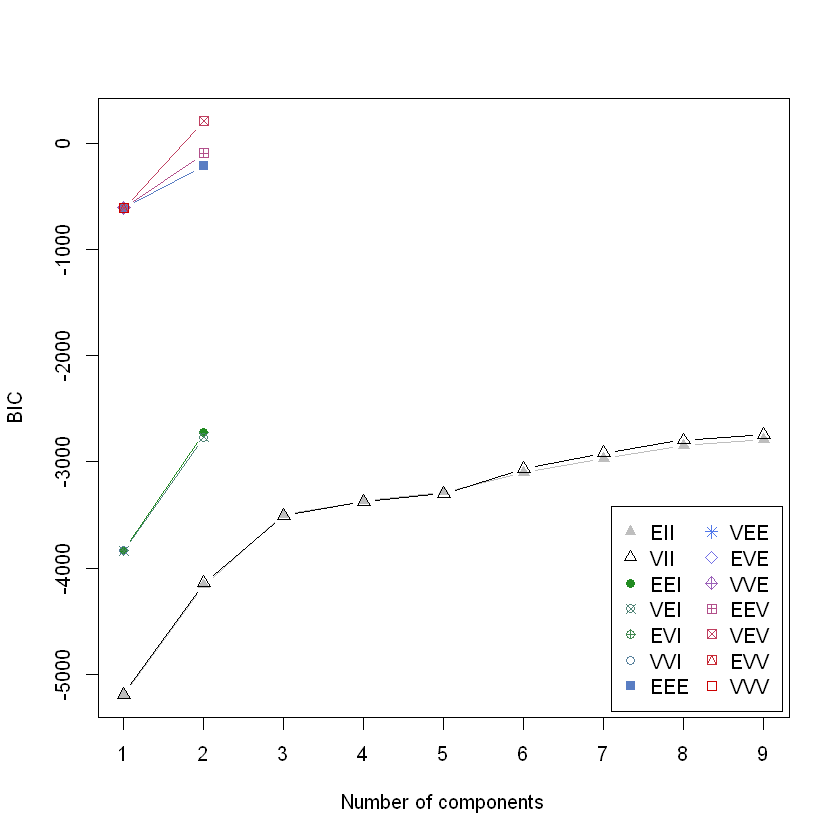

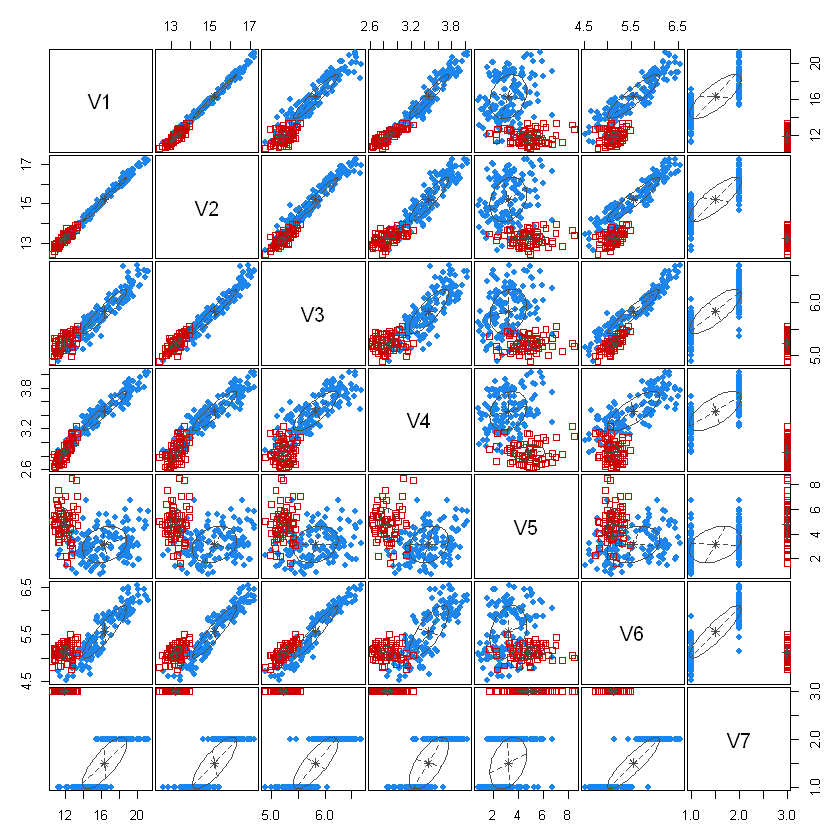

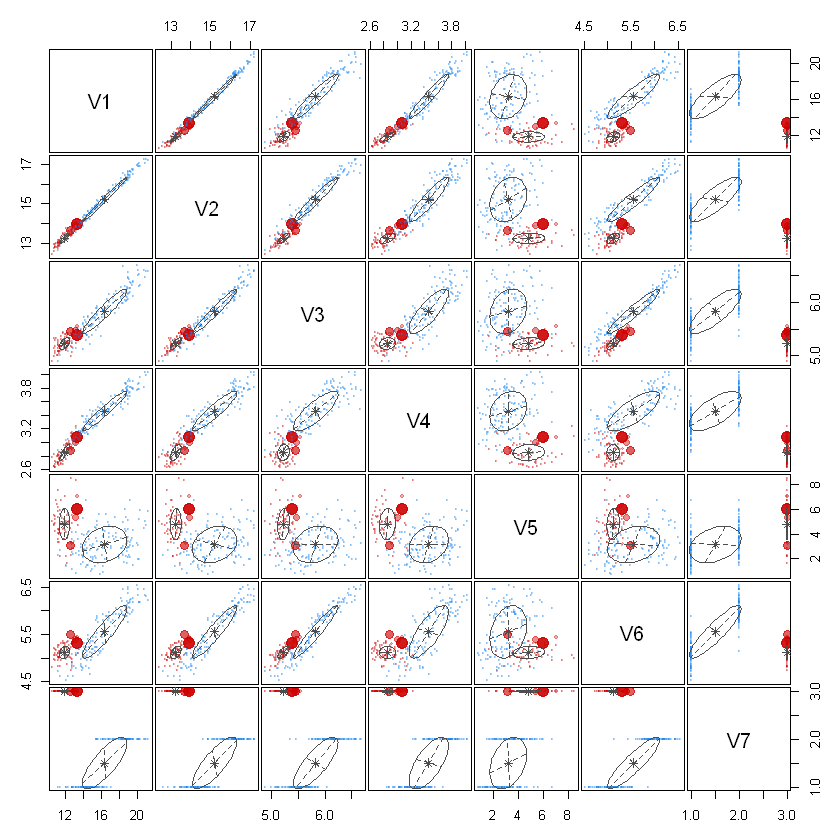

'Mclust' model object: (VEV,2) 

Available components: 
 [1] "call"           "data"           "modelName"      "n"             
 [5] "d"              "G"              "BIC"            "loglik"        
 [9] "df"             "bic"            "icl"            "hypvol"        
[13] "parameters"     "z"              "classification" "uncertainty"   

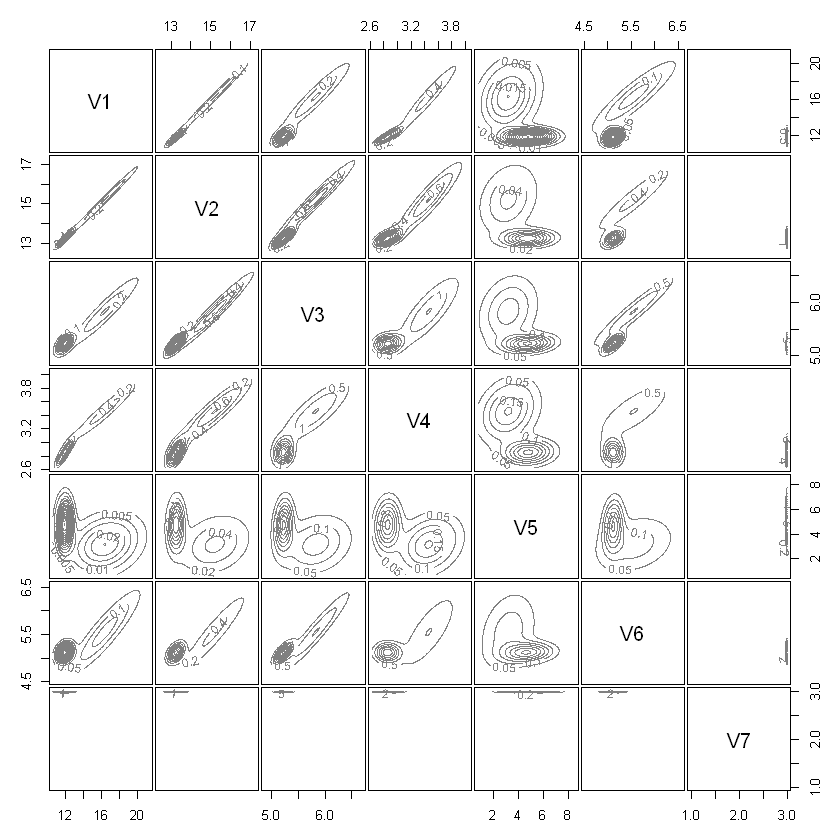

In [2]:
clus <-Mclust(datos1)
summary(clus)
par(bg = "white")
plot(clus)
clus


# Ejercicio 1
## a) Explique como funciona el método Mclust, describa los principales parámetros de entrada y salida.


### R: El método mclust implementa un enfoque clustering basado en modelos donde se asume que los datos provienen de una mezcla de distribuciones gaussianas. A partir de esto, estima iterativamente los parámetros de cada componente (medias, covarianzas y proporciones) mediante el algoritmo 'Expectation-Maximization'. Además el método prueba distintos números de clusters y distintas estructuras de covarianza, y selecciona el modelo que mejor equilibra ajuste y complejidad utilizando el Criterio de Información Bayesiano(BIC). Finalmente, asigna cada observación al grupo con mayor probabilidad.

### En cuanto a los parámetros de entrada, recibe una matriz de datos numéricos con las observaciones (data), número de clusters a evaluar (G), los tipos de modelos de covarianza (modelNames), y puede incluir otras opciones de inicialización y control del algoritmo. Como salida, devuelve un objeto con múltiples componentes útiles para interpretar el modelo: 

  ### - **call:** la llamada original a la función.
  
  ### - **data:** los datos de entrada.

  ### - **modelName:** nombre del modelo seleccionado como óptimo.

  ### - **n:** número de observaciones.

  ### - **d:** dimensión de los datos (número de variables).

  ### - **G:** número óptimo de componentes de mezcla.

  ### - **BIC:** valores del criterio de información bayesiano para los modelos evaluados.

  ### - **loglik:** log-verosimilitud del modelo óptimo.

  ### - **parameters:** lista con los parámetros estimados (medias, varianzas, proporciones de mezcla).

  ### - **z:** matriz de probabilidades de pertenencia de cada observación a cada componente.

  ### - **classification:** vector con la asignación final de cada observación a un cluster.

## b) Utilice Mclust sin definir el número de grupos y considere el Criterio de información Bayesiano (BIC) para decidir el número de grupos óptimo.

### R: La información entregada al ejecutar el método Mclust sin definir el número de grupos fue la siguiente:

### Mclust VEV (ellipsoidal, equal shape) model with 2 components: 

### **log-likelihood**: 276.8603;   **n**: 210;   **df**: 65;   **BIC**: 206.1586;   **ICL**: 206.1586

### Con 210 observaciones y un BIC de 206.1586, el número de grupos óptimo es 2.

## c) Interprete y comente los resultados obtenidos. Compare sus resultados con aquellos obtenidos con k-means.

### R: Lo más notorio al observar los resultados es el hecho de que el clustering resultante es muy asimétrico: un gran cluster de 140 observaciones y un cluster más pequeño de 70 observaciones. En el gráfico de BIC se muestra claramente que los modelos con 2 componentes dominan sobre otras configuraciones (como 1 o 3+), con el modelo VEV alcanzando el BIC más alto (206 aprox.). En los demás gráficos se observa que la separación entre el grupo 1 (mayoritario) y el grupo 2 (minoritario) es clara en varias proyecciones.

### La comparación entre ambos métodos revela una discrepancia en la solución encontrada: Mclust prefiere una solución más simple con 2 clusters, mientras que K-Means detecta 3 grupos distintos. Del lado de Mclust, la elección del modelo VEV indica que los clusters no son esféricos. Del lado de K-Means, al forzar la esfericidad, necesita más clusters (3) para ajustar una distribución que un Mclust puede modelar con menos componentes (2) pero de forma elipsoidal. Esto debido a que, según el BIC, la complejidad añadida de modelar las covarianzas para 3 grupos (27 parámetros adicionales) no se justifica por la mejora en la verosimilitud, por lo que penaliza esta complejidad. El K-Means, al asumir estructuras esféricas, encuentra que 3 grupos es una estructura mejor que una distribución aleatoria.

# Ejercicio 2
## a) Estudie las medidas de calidad propuestas en Murphy, Capítulo 25: purity, rand index y mutual information (pdf en siveducMD) y resuma brevemente en que consisten.

En el capítulo 25 del libro "Murphy Machine Learning", se habla de clustering, iniciando por el tópico de medidas de calidad de estos métodos, con el fin de compararlos. Es en este contexto que el libro define 3 métodos para evaluar lo entregado por los métodos de clustering, específicamente cuando se tienen datos con etiqueta, estos son:

- ### **Purity**

Mide la homogeneidad de los clusters encontrados, promediando las purezas individualdes de cada clúster, ponderado por el tamaño relativo de cada clúster respecto al total de la población:

$$Purity = \sum_{i} \frac{N_{i}}{N}\max_{j}(p_{ij})$$

Donde:
* $N_{i}$ es el tamaño del cluster $i$. 
* $N$ es el total de datos.
* $p_{ij} = \frac{N_{ij}}{N_{i}}$ es la probabilidad de que un elemento del cluster $i$ pertenezca a la clase $j$.

Tiene valores desde el 0 (malo) hasta el 1 (bueno), aunque cabe mencionar que se logran purezas altas, o perfectas, al separar los elementos de distintas clases en sus propiosn clusters.


- ### **Rand Index**

Mide la proporción de desiciones de agrupación correctas, comparando el clustering obtenido como uno de referencia. Se basa en evaluar todo slos pares de objetos posibles y reficiar si el algoritmo los agrupó de la misma forma que la referencia (clases reales)-

$$R = \frac{TP + TN}{TP + FP + FN + TN}$$

Donde:
* $TP$ son los Verdaderos Positivos (Pares de puntos que están en el mismo clúster, tanto en resultado como en la referencia).
* $TN$ son los Verdaderos Negativos (Pares de pountos que están en clusters diferentes en ambos casos).
* $FP$ y $FN$ son las decisiones incorrectas (Päres que el algoritmo agrupó o separó mal).

Tiene valores desde el 0 (malo) hasta el 1 (bueno).

- ### **Mutual Information**

Mide cuanta información comparten la partición obtenida ($U$) y la de referencia ($V$). Utiliza conceptos de la teoría de la información para evaluar cuánto reduce el conocimiento de los clusters la incertidumbre sobre las clases reales.

$$I(U,V) = \sum_{i=1}^{R}\sum_{j=1}^{C}P_{UV}(i,j) log\frac{P_{UV}(i,j)}{P_{U}(i)P_{V}(j)}$$

Donde:
* $P_{UV}(i,j)$ Entrega la probabilidad de que un objeto pertenezca al cluster $u_{i}$ y a la clase $v_{j}$ simultáneamente.
* $P_{U}(i)$ y $P_{V}(j)$ son las probabilidades marginales de pertenecer al cluster $i$ o a la clase $j$.

Murphy señala la problemática de inflación por repartos con muchos clusters pequeños, por ello se prefiere la versión normalizada de Mutual Information, que escala el valor entre 0 y 1.

### Considere el archivo "semillas.txt" que contiene una séptima variable con la clasificación de las semillas en tres variedades: 
### - 1: Kama
### - 2: Rosa
### - 3: Canadian

## b) Calcule alguna de las medidas de caliudad estudiadas para los agrupamientos obtenidos con k-means (tarea anterior) y GMM, considerando la etiqueta en V7 para sus cálculos. Compare y discuta sus resultados



In [7]:
# Librerias para clustering y visualizacion
library(factoextra)

# Definicion de etiqueta real (V7) y matriz de variables
col_etiqueta <- 7
y_real <- as.factor(datos1[, col_etiqueta])
datos <- datos1[, -col_etiqueta]

# Escalado (mismo criterio usado en el trabajo anterior)
datos_scaled <- scale(datos)

# Funcion de pureza
purity_score <- function(y_true, y_pred) {
  tab <- table(y_pred, y_true)
  sum(apply(tab, 1, max)) / sum(tab)
}

In [8]:
# K-means con k fijo en 3 (consistente con ejercicio anterior)
k0 <- 3
set.seed(123)
cl <- kmeans(datos_scaled, k0, iter.max = 1000, nstart = 50)

purity_kmeans <- purity_score(y_real, cl$cluster)

cat("Purity k-means (k=3):", round(purity_kmeans, 4), "\n")
cat("\nTabla cluster vs clase real (k-means):\n")
print(table(cl$cluster, y_real))

Purity k-means (k=3): 0.9095 

Tabla cluster vs clase real (k-means):
   y_real
     1  2  3
  1  8  0 65
  2 60  4  5
  3  2 66  0


Purity GMM (G=3): 0.9429 

Tabla cluster vs clase real (GMM):
     y_real
y_gmm  1  2  3
    1  0 69  0
    2 11  0 70
    3 59  1  0

Comparacion:
k-means: 0.9095 
GMM    : 0.9429 


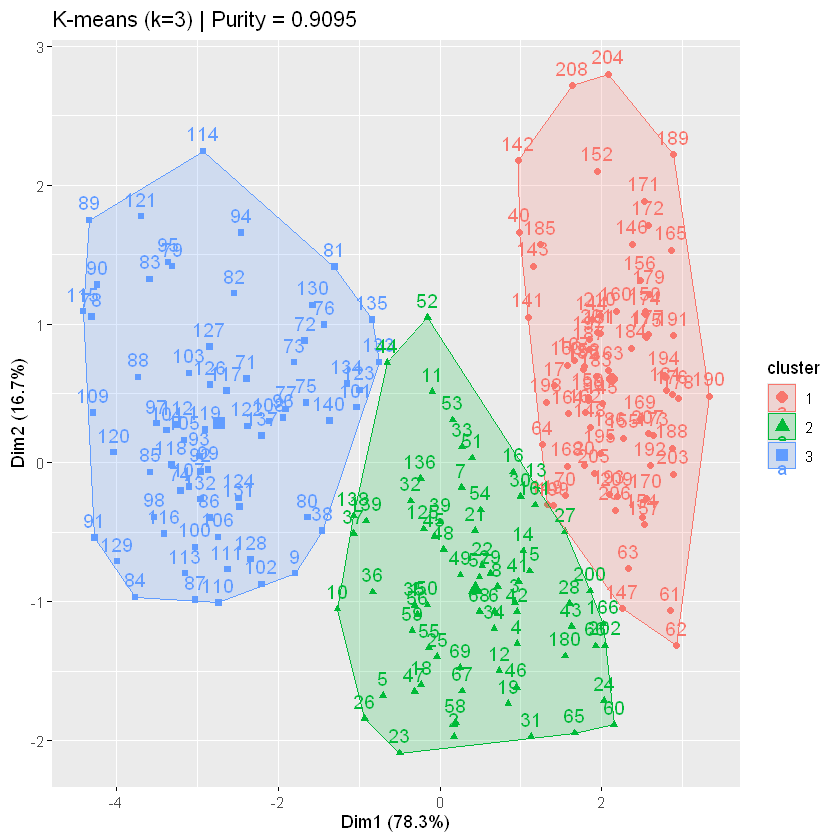

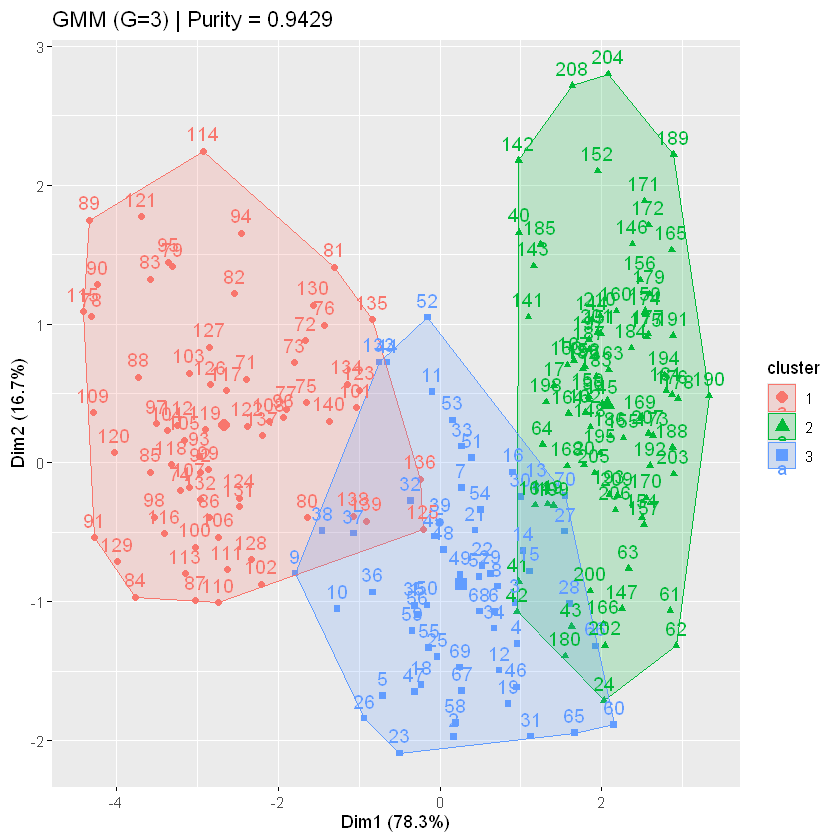

In [9]:
# GMM con mismo numero de grupos
set.seed(123)
clus <- Mclust(datos_scaled, G = k0)
y_gmm <- clus$classification

purity_gmm <- purity_score(y_real, y_gmm)

cat("Purity GMM (G=3):", round(purity_gmm, 4), "\n")
cat("\nTabla cluster vs clase real (GMM):\n")
print(table(y_gmm, y_real))

cat("\nComparacion:\n")
cat("k-means:", round(purity_kmeans, 4), "\n")
cat("GMM    :", round(purity_gmm, 4), "\n")

# K-means
fviz_cluster(cl, df) +
  ggtitle(paste0("K-means (k=3) | Purity = ", round(purity_kmeans, 4)))

# GMM
cl_gmm <- list(data = df, cluster = y_gmm)
fviz_cluster(cl_gmm, df) +
  ggtitle(paste0("GMM (G=3) | Purity = ", round(purity_gmm, 4)))

Se comparó la calidad de los agrupamientos obtenidos con K-means (k=3) y GMM (g=3) usando la métrica Purity, descrita previamente en 2.a), con la cual se obtienen los siguientes resultados:

|Método|Purity|
| --- | --- |
|K-means|0.9095|
|GMM|0.9429|

Esto nos indica que GMM muestra una mejor capacidad de separar las tres variedades de semillas que K-means, además, en los últimos dos gráficos se observa también cómo GMM puede modelar grupos con formas más flexibles que K-means, que tiende a ser más esférico.

# Ejercicio 3 (Grupo16.csv)

## a) Realice el análisis de agrupamiento de los datos asignados a su grupo utilizando GMM

## b) Interprete sus resultados y compare con los obtenidos con k-means.